In [161]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, hamming_loss
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier
from skmultilearn.model_selection import iterative_train_test_split
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import seaborn as sns
from sklearn.metrics import roc_auc_score

df = pd.read_csv("./data_cleaned/mines.csv")
df.drop(columns=["MagSus_SI"], inplace=True)
df.head()

,province,longitude,latitude,Vp_100_kms,Density_gcc,elevation,SiO2_pct,Al2O3_pct,Fe2O3_pct,MgO_pct,...,Cobalt,Copper,Diamond,Gold,Graphite,Lithium,Nickel,Rare Earth Elements (REE),Silver,Uranium
0,Alberta,-119.259533,54.028620,6.156535,2.741558,1526.0,10.080060,1.344176,0.915702,0.782849,...,0,0,0,0,0,0,0,0,0,0
1,Alberta,-119.178389,53.938609,6.003050,2.702220,997.0,10.509113,1.494849,1.472888,0.639297,...,0,0,0,0,0,0,0,0,0,0
2,Alberta,-119.166700,54.033300,6.156684,2.741491,1256.0,10.887126,1.341847,0.928192,0.781493,...,0,0,0,0,0,0,0,0,0,0
3,Alberta,-117.508710,53.093082,5.870413,2.768604,1757.0,31.763702,5.646134,7.142402,0.160068,...,0,0,0,0,0,0,0,0,0,0
4,Alberta,-117.460447,53.607195,5.845066,2.725312,1444.0,19.958529,4.739211,4.412431,0.395807,...,0,0,0,0,0,0,0,0,0,0


In [162]:
targets = [
    'Cobalt',
    'Copper',
    'Diamond',
    'Gold',
    'Graphite',
    'Lithium',
    'Nickel',
    'Rare Earth Elements (REE)',
    'Silver',
    'Uranium'
]

features = ['longitude', 'latitude', 'Vp_100_kms', 'Density_gcc',
       'elevation', 'SiO2_pct', 'Al2O3_pct', 'Fe2O3_pct', 'MgO_pct', 'CaO_pct',
       'Na2O_pct', 'K2O_pct', 'TiO2_pct', 'P2O5_pct', 'MnO_pct', 'Au_ppb',
       'Cu_ppm', 'Ni_ppm', 'Co_ppm', 'Li_ppm', 'Cr_ppm', 'Zn_ppm', 'Pb_ppm',
       'Mo_ppm', 'As_ppm', 'Th_ppm', 'U_ppm', 'La_ppm', 'Ce_ppm', 'Nd_ppm',
       'Nb_ppm', 'V_ppm', 'W_ppm'
]

len(features)


33

In [163]:
np.random.seed(42)

X = df[features]
y = df[targets].values

X_train, y_train, X_test, y_test = iterative_train_test_split(X.values, y, test_size=0.2)

In [164]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [165]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


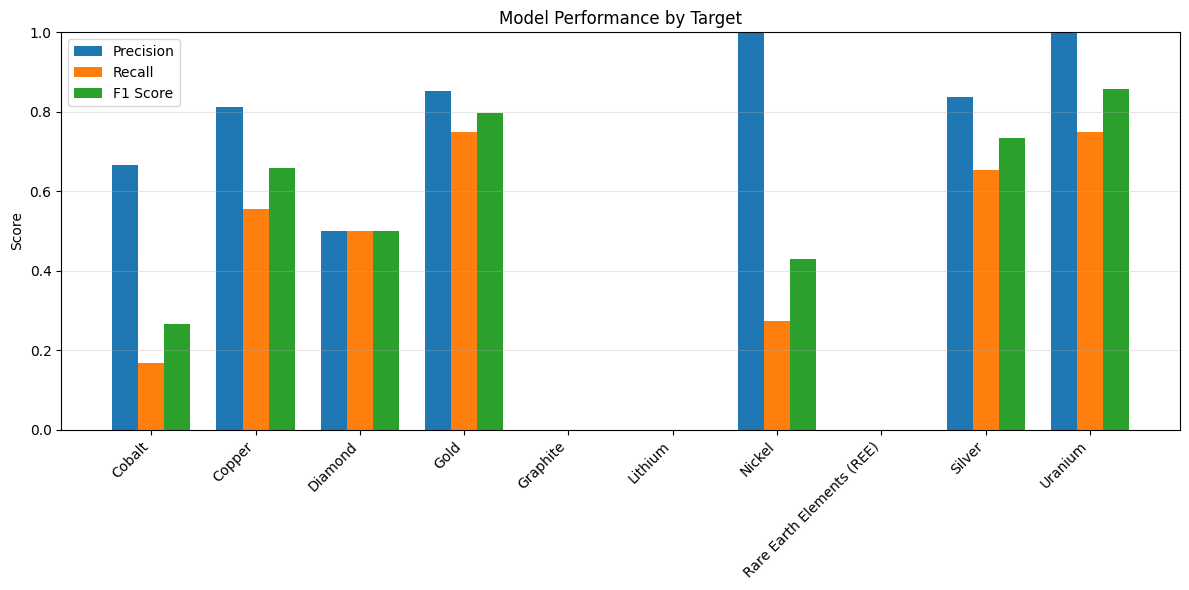

In [166]:
y_pred = model.predict(X_test_scaled)

f1 = f1_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)

x = np.arange(len(targets))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1 Score')

plt.xticks(x, targets, rotation=45, ha='right') 
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance by Target")
plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [167]:
print("Hamming Loss:", hamming_loss(y_test, y_pred))
for i, target in enumerate(targets):
    print(f"\n{target}:")
    print(classification_report(y_test[:, i], y_pred[:, i]))

Hamming Loss: 0.06514285714285714

Cobalt:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       163
           1       0.67      0.17      0.27        12

    accuracy                           0.94       175
   macro avg       0.80      0.58      0.62       175
weighted avg       0.92      0.94      0.92       175


Copper:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88       121
           1       0.81      0.56      0.66        54

    accuracy                           0.82       175
   macro avg       0.82      0.75      0.77       175
weighted avg       0.82      0.82      0.81       175


Diamond:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       173
           1       0.50      0.50      0.50         2

    accuracy                           0.99       175
   macro avg       0.75      0.75      0.75       175
weighted avg

c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [168]:
top_targets = [
    'Copper',
    'Diamond',
    'Gold',
    'Silver'
]

features = ['longitude', 'latitude', 'Vp_100_kms', 'Density_gcc',
       'elevation', 'SiO2_pct', 'Al2O3_pct', 'Fe2O3_pct', 'MgO_pct', 'CaO_pct',
       'Na2O_pct', 'K2O_pct', 'TiO2_pct', 'P2O5_pct', 'MnO_pct', 'Au_ppb',
       'Cu_ppm', 'Ni_ppm', 'Co_ppm', 'Li_ppm', 'Cr_ppm', 'Zn_ppm', 'Pb_ppm',
       'Mo_ppm', 'As_ppm', 'Th_ppm', 'U_ppm', 'La_ppm', 'Ce_ppm', 'Nd_ppm',
       'Nb_ppm', 'V_ppm', 'W_ppm'
]

X = df[features]
y = df[top_targets].values

X_train, y_train, X_test, y_test = iterative_train_test_split(X.values, y, test_size=0.2)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Hamming Loss:", hamming_loss(y_test, y_pred))
for i, target in enumerate(top_targets):
    report = classification_report(y_test, y_pred, output_dict=True)
    precision_1 = report["1"]["precision"] # type: ignore
    recall_1 = report["1"]["recall"] # type: ignore
    f1_1 = report["1"]["f1-score"] # type: ignore
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n{target}:")
    print("Precision:", precision_1)
    print("Recall:", recall_1)
    print("F1:", f1_1)
    print("Accuracy:", accuracy)

Hamming Loss: 0.22857142857142856

Copper:
Precision: 0.0
Recall: 0.0
F1: 0.0
Accuracy: 0.46285714285714286

Diamond:
Precision: 0.0
Recall: 0.0
F1: 0.0
Accuracy: 0.46285714285714286

Gold:
Precision: 0.0
Recall: 0.0
F1: 0.0
Accuracy: 0.46285714285714286

Silver:
Precision: 0.0
Recall: 0.0
F1: 0.0
Accuracy: 0.46285714285714286


c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

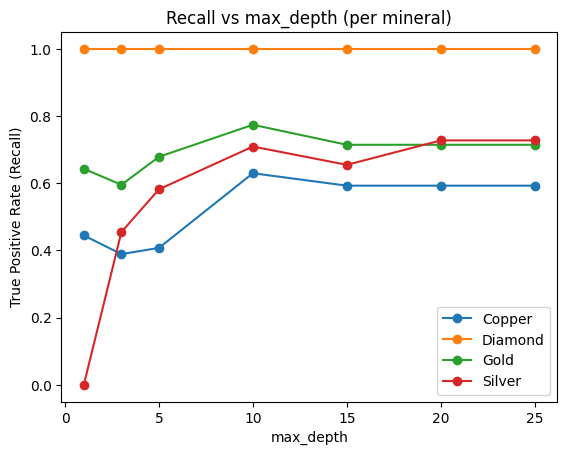

In [169]:
depths = [1, 3, 5, 10, 15, 20, 25]
recall_per_target = []

for d in depths:
    model = MultiOutputClassifier(
        DecisionTreeClassifier(max_depth=d, random_state=42)
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    recalls = recall_score(y_test, y_pred, average=None)
    recall_per_target.append(recalls)

recall_per_target = np.array(recall_per_target)

plt.figure()

for i, name in enumerate(top_targets):
    plt.plot(
        depths,
        recall_per_target[:, i],
        marker='o',
        label=name
    )

plt.xlabel("max_depth")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Recall vs max_depth (per mineral)")
plt.legend()
plt.show()

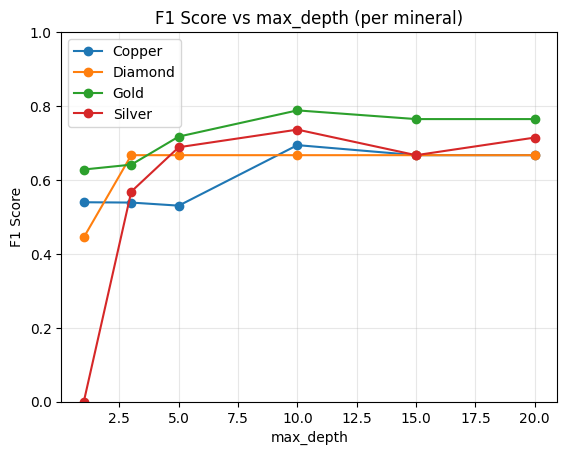

In [170]:
from sklearn.metrics import f1_score


depths = [1, 3, 5, 10, 15, 20]
f1_scores_per_target = []

for d in depths:
    model = MultiOutputClassifier(
        DecisionTreeClassifier(max_depth=d, random_state=42)
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    scores = f1_score(y_test, y_pred, average=None)
    f1_scores_per_target.append(scores)

f1_scores_per_target = np.array(f1_scores_per_target)

plt.figure()

for i, name in enumerate(top_targets):
    plt.plot(
        depths,
        f1_scores_per_target[:, i],
        marker='o',
        label=name
    )

plt.xlabel("max_depth")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.title("F1 Score vs max_depth (per mineral)")
plt.legend()
plt.show()

Criterion: gini [0.66666667 0.66666667 0.76433121 0.71428571]
Criterion: entropy [0.74747475 0.66666667 0.79041916 0.73684211]
Criterion: log_loss [0.74747475 0.66666667 0.79041916 0.73684211]


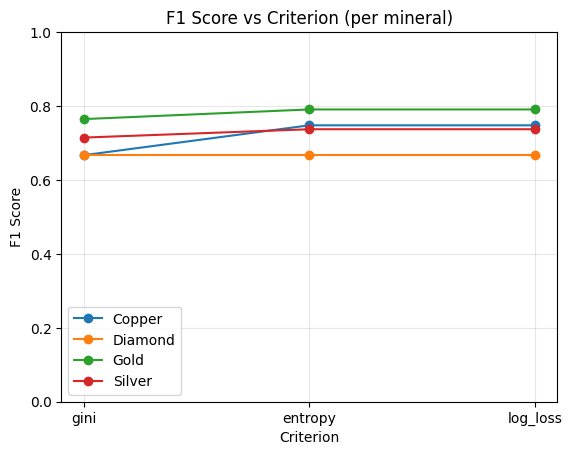

In [171]:
criterion = ["gini", "entropy", "log_loss"]
f1_scores_per_target = []

for c in criterion:
    model = MultiOutputClassifier(
        DecisionTreeClassifier(max_depth=d, random_state=42, criterion = c) # type: ignore
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    scores = f1_score(y_test, y_pred, average=None)
    print(f"Criterion: {c}", scores)
    f1_scores_per_target.append(scores)

f1_scores_per_target = np.array(f1_scores_per_target)

plt.figure()

for i, name in enumerate(top_targets):
    plt.plot(
        criterion,
        f1_scores_per_target[:, i],
        marker='o',
        label=name
    )

plt.xlabel("Criterion")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.title("F1 Score vs Criterion (per mineral)")
plt.legend()
plt.show()

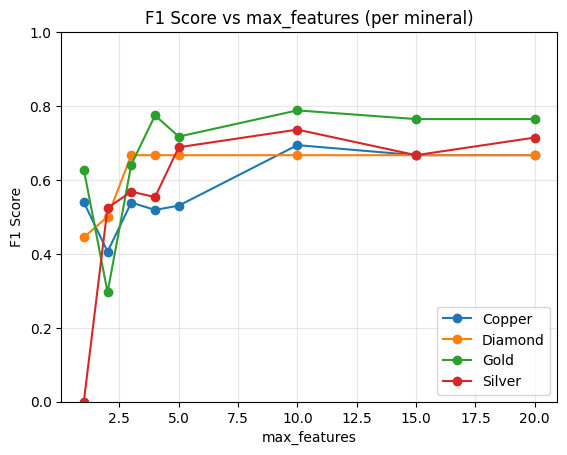

In [172]:
max_features = [1, 2, 3, 4, 5, 10, 15, 20]
f1_scores_per_target = []

for m in max_features:
    model = MultiOutputClassifier(
        DecisionTreeClassifier(max_depth=m, random_state=42)
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    scores = f1_score(y_test, y_pred, average=None)
    f1_scores_per_target.append(scores)

f1_scores_per_target = np.array(f1_scores_per_target)

plt.figure()

for i, name in enumerate(top_targets):
    plt.plot(
        max_features,
        f1_scores_per_target[:, i],
        marker='o',
        label=name
    )

plt.xlabel("max_features")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.title("F1 Score vs max_features (per mineral)")
plt.legend()
plt.show()


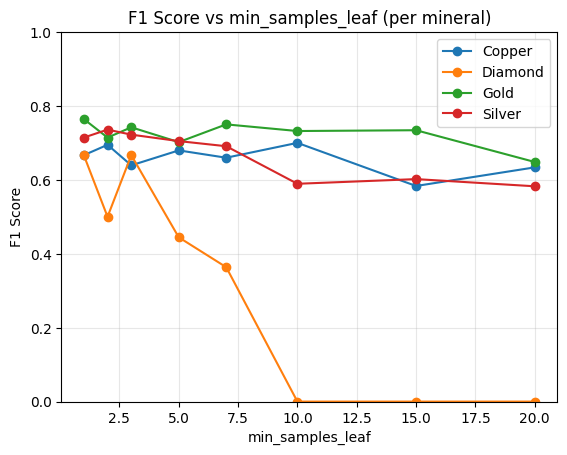

In [173]:
min_samples_leaf = [1, 2, 3, 5, 7, 10, 15, 20]
f1_scores_per_target = []

for m in min_samples_leaf:
    model = MultiOutputClassifier(
        DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    scores = f1_score(y_test, y_pred, average=None)
    f1_scores_per_target.append(scores)

f1_scores_per_target = np.array(f1_scores_per_target)

plt.figure()

for i, name in enumerate(top_targets):
    plt.plot(
        min_samples_leaf,
        f1_scores_per_target[:, i],
        marker='o',
        label=name
    )

plt.xlabel("min_samples_leaf")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.title("F1 Score vs min_samples_leaf (per mineral)")
plt.legend()
plt.show()

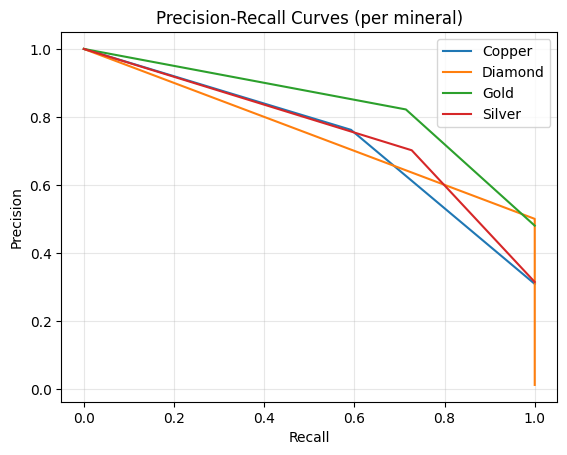

In [174]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.multioutput import MultiOutputClassifier
from sklearn.tree import DecisionTreeClassifier

model = MultiOutputClassifier(
    DecisionTreeClassifier(random_state=42)
)
model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)

plt.figure()

for i, name in enumerate(top_targets):
    proba = y_proba[i][:, 1]

    precision, recall, _ = precision_recall_curve(y_test[:, i], proba)

    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (per mineral)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [175]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, recall_score, precision_score

model = MultiOutputClassifier(
    DecisionTreeClassifier(random_state=42)
)

param_grid = {
    "estimator__max_depth": [1, 3, 5, 10, 15, 20, None],
    "estimator__min_samples_split": [2, 5, 10, 20],
    "estimator__min_samples_leaf": [1, 2, 5, 10],
    "estimator__criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    model,
    param_grid,
    scoring="recall_macro",   # important for multi-output
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)

for i, t in enumerate(top_targets):
    print(f"\n{t}")
    print(f"Precision: {precision[i]:.3f}")
    print(f"Recall:    {recall[i]:.3f}")
    print(f"F1 Score:  {f1[i]:.3f}")

Fitting 5 folds for each of 224 candidates, totalling 1120 fits
{'estimator__criterion': 'gini', 'estimator__max_depth': 15, 'estimator__min_samples_leaf': 5, 'estimator__min_samples_split': 2}
0.41091072661418754

Copper
Precision: 0.714
Recall:    0.648
F1 Score:  0.680

Diamond
Precision: 0.286
Recall:    1.000
F1 Score:  0.444

Gold
Precision: 0.791
Recall:    0.631
F1 Score:  0.702

Silver
Precision: 0.740
Recall:    0.673
F1 Score:  0.705


In [176]:
X = df[features]
y_full = df[targets].values

X_train, y_train, X_test, y_test = iterative_train_test_split(X.values, y_full, test_size=0.2)

model = MultiOutputClassifier(
    DecisionTreeClassifier(random_state=42)
)

param_grid = {
    "estimator__max_depth": [1, 3, 5, 10, 15, 20, None],
    "estimator__min_samples_split": [2, 5, 10, 20],
    "estimator__min_samples_leaf": [1, 2, 5, 10],
    "estimator__criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    model,
    param_grid,
    scoring="recall_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print(grid.best_params_)
print(grid.best_score_)

y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)

for i, t in enumerate(targets):
    print(f"\n{t}")
    print(f"Precision: {precision[i]:.3f}")
    print(f"Recall:    {recall[i]:.3f}")
    print(f"F1 Score:  {f1[i]:.3f}")

y_proba = best_model.predict_proba(X_test)
auc_scores = []

for i in range(len(targets)):
    if len(np.unique(y_test[:, i])) < 2:
        auc_scores.append(0)
    else:
        auc = roc_auc_score(y_test[:, i], y_proba[i][:, 1])
        auc_scores.append(auc)

auc_scores = np.array(auc_scores)

print(auc_scores)

Fitting 5 folds for each of 224 candidates, totalling 1120 fits
{'estimator__criterion': 'entropy', 'estimator__max_depth': 10, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2}
0.20845050195207673

Cobalt
Precision: 0.333
Recall:    0.300
F1 Score:  0.316

Copper
Precision: 0.667
Recall:    0.593
F1 Score:  0.627

Diamond
Precision: 0.667
Recall:    1.000
F1 Score:  0.800

Gold
Precision: 0.771
Recall:    0.762
F1 Score:  0.766

Graphite
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Lithium
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Nickel
Precision: 0.500
Recall:    0.455
F1 Score:  0.476

Rare Earth Elements (REE)
Precision: 0.000
Recall:    0.000
F1 Score:  0.000

Silver
Precision: 0.600
Recall:    0.655
F1 Score:  0.626

Uranium
Precision: 0.800
Recall:    1.000
F1 Score:  0.889
[0.57242424 0.72903275 0.99710983 0.79330194 0.5        0.5
 0.71036585 0.         0.76825758 0.99707602]


c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

In [183]:
for i in range(len(targets)):
    print(f"{targets[i]}: {(y_test[:, i] == 1).sum()} positives, {(y_test[:, i] == 0).sum()} negatives")

Cobalt: 10 positives, 165 negatives
Copper: 54 positives, 121 negatives
Diamond: 2 positives, 173 negatives
Gold: 84 positives, 91 negatives
Graphite: 1 positives, 174 negatives
Lithium: 1 positives, 174 negatives
Nickel: 11 positives, 164 negatives
Rare Earth Elements (REE): 0 positives, 175 negatives
Silver: 55 positives, 120 negatives
Uranium: 4 positives, 171 negatives


c:\Users\jylis\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


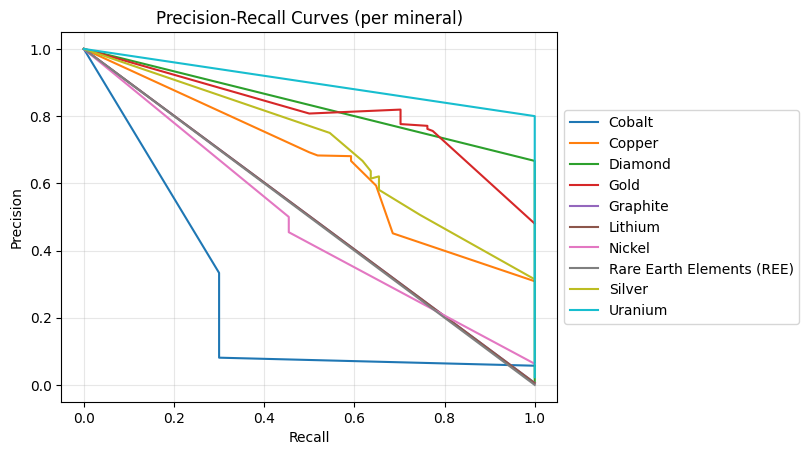

In [ ]:
# plt.figure()

# for i, name in enumerate(targets):
#     proba = y_proba[i][:, 1]

#     precision, recall, _ = precision_recall_curve(y_test[:, i], proba)

#     plt.plot(recall, precision, label=name)

# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title("Precision-Recall Curves (per mineral)")
# plt.grid(alpha=0.3)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.show()

C:\Users\jylis\AppData\Local\Temp\ipykernel_17476\2809527170.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


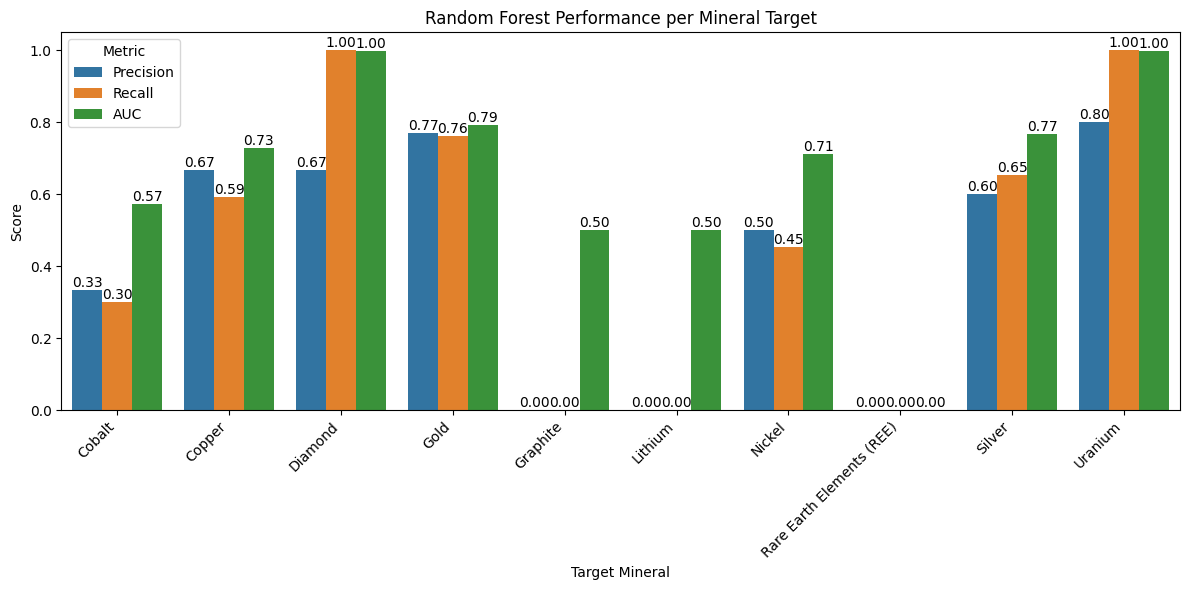

In [178]:
metrics_df = pd.DataFrame({
    "Target Mineral": targets,
    # "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "AUC": auc_scores
})

metrics_long = metrics_df.melt(
    id_vars="Target Mineral",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=metrics_long,
    x="Target Mineral",
    y="Score",
    hue="Metric"
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Random Forest Performance per Mineral Target")
plt.tight_layout()
plt.show()

In [179]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance_df)

        feature  importance
10     Na2O_pct    0.155429
16       Cu_ppm    0.154857
2    Vp_100_kms    0.090857
28       Ce_ppm    0.056000
9       CaO_pct    0.053143
18       Co_ppm    0.052571
19       Li_ppm    0.048000
17       Ni_ppm    0.040571
6     Al2O3_pct    0.038857
4     elevation    0.036000
5      SiO2_pct    0.033143
32        W_ppm    0.032571
0     longitude    0.031429
14      MnO_pct    0.030857
23       Mo_ppm    0.030857
3   Density_gcc    0.029714
22       Pb_ppm    0.021714
25       Th_ppm    0.021143
1      latitude    0.020571
31        V_ppm    0.020571
7     Fe2O3_pct    0.017714
13     P2O5_pct    0.016571
24       As_ppm    0.010286
21       Zn_ppm    0.008000
11      K2O_pct    0.008000
27       La_ppm    0.004000
15       Au_ppb    0.004000
29       Nd_ppm    0.002857
8       MgO_pct   -0.001143
26        U_ppm   -0.001714
30       Nb_ppm   -0.004000
12     TiO2_pct   -0.005143
20       Cr_ppm   -0.005714
